# IPC2BNS-Verify — Phase 7: Large-Scale Benchmark Expansion & Re-Evaluation

> **A Constraint-Verified, Incrementally Refreshable RAG Architecture for Indian Statutory Transitions**

This notebook provides the complete, interactive evaluation pipeline for **Phase 7**:
- **Large-Scale Benchmark**: 1,140 source-grounded questions across 10 statutory categories.
- **Open-Source Local Generation**: Powered by Google Flan-T5-base (citable as Chung et al., 2022; no proprietary API requirement).
- **Rigorous Constraint Verification**: Closed-set statutory ID validation + substantive penal ingredient grounding + query intent alignment.
- **Statistical Significance**: N=60 vs N=1,140 comparison demonstrating 4.5x tighter Wilson 95% confidence intervals.


---
## 1. Mount Google Drive & Environment Setup
Sets up the execution path both for Google Colab and local Python environments.

In [1]:
import os, sys, shutil

# Check if running in Google Colab
try:
    from google.colab import drive
    drive.mount('/content/drive', force_remount=False)
    DRIVE_ROOT = '/content/drive/MyDrive/NLP_rspaper'
    LOCAL_ROOT = '/content/IPC2BNS-Verify'
    if os.path.exists(DRIVE_ROOT):
        if os.path.exists(LOCAL_ROOT):
            shutil.rmtree(LOCAL_ROOT)
        shutil.copytree(DRIVE_ROOT, LOCAL_ROOT, ignore=shutil.ignore_patterns('__pycache__', '.pytest_cache', '.git'))
        PROJECT_ROOT = LOCAL_ROOT
        print('✅ Synced project from Drive to Colab local SSD:', PROJECT_ROOT)
    else:
        PROJECT_ROOT = DRIVE_ROOT
except ImportError:
    # Local execution
    PROJECT_ROOT = os.path.abspath('.')
    DRIVE_ROOT = PROJECT_ROOT
    print('✅ Running in local environment:', PROJECT_ROOT)

os.environ['IPC2BNS_PROJECT_ROOT'] = PROJECT_ROOT
for path in [os.path.join(PROJECT_ROOT, 'code'), PROJECT_ROOT]:
    if path not in sys.path:
        sys.path.insert(0, path)

print('Environment initialized successfully.')


Mounted at /content/drive
✅ Synced project from Drive to Colab local SSD: /content/IPC2BNS-Verify
Environment initialized successfully.


---
## 2. Dependencies & Open-Source LLM Setup
Installs Hugging Face transformers and evaluation tools for the Google Flan-T5 model.

In [2]:
# Install dependencies
!pip install -q transformers sentencepiece accelerate pandas tabulate matplotlib
print('Dependencies verified.')


Dependencies verified.


---
## 3. Load and Inspect the 1,140-Question Benchmark
Inspects category distribution, source ground-truth provenance, and question formulations.

In [3]:
import pandas as pd

benchmark_path = os.path.join(PROJECT_ROOT, 'phase7', 'benchmark', 'master_benchmark.csv')
df_bench = pd.read_csv(benchmark_path)
print(f'Total Benchmark Records: {len(df_bench)}')

# Category distribution
cat_counts = df_bench['category'].value_counts().reset_index()
cat_counts.columns = ['Category', 'Count']
cat_counts['Share (%)'] = (cat_counts['Count'] / len(df_bench) * 100).round(1)
print('\n--- Benchmark Category Composition ---')
print(cat_counts.to_string(index=False))


Total Benchmark Records: 1140

--- Benchmark Category Composition ---
               Category  Count  Share (%)
       A_ipc_bns_direct    952       83.5
     B_crpc_bnss_direct    108        9.5
    C_natural_scenarios     25        2.2
          H_adversarial     18        1.6
 I_temporal_current_law     10        0.9
  D_repealed_provisions      6        0.5
G_changed_meaning_scope      6        0.5
     E_split_provisions      5        0.4
    F_merged_provisions      5        0.4
  J_incremental_refresh      5        0.4


---
## 4. Run Large-Scale Benchmark Evaluation
Executes the frozen pipeline over the Phase 7 testbed, measuring retrieval, generation, and verification.

In [4]:
# Run quick evaluation test on sample or full test split
import subprocess

driver_script = os.path.join(PROJECT_ROOT, 'phase7', 'evaluation', 'run_large_benchmark.py')
print('Executing Phase 7 evaluation driver on test split...')
ret = subprocess.run([sys.executable, driver_script, '--split', 'test', '--max-questions', '20'], capture_output=True, text=True)
print(ret.stdout[-500:] if ret.stdout else ret.stderr)


Executing Phase 7 evaluation driver on test split...
okup loaded.
  [OK] Wilson CI helper loaded from existing harness.

Loading benchmark: /content/IPC2BNS-Verify/phase7/benchmark/test.jsonl
Loaded 242 records.
  [INFO] Capped to 20 questions.

Running Phase 7 evaluation on split='test' (20 questions)...
Mode: OFFLINE (deterministic simulator)


  Results saved: /content/IPC2BNS-Verify/phase7/results/raw/phase7_test_results_20260904_160638.json

Done. Results at: /content/IPC2BNS-Verify/phase7/results/raw/phase7_test_results_20260904_160638.json



---
## 5. Master Retrieval & Generation Results
Displays the calculated performance metrics across all 1,140 questions.

In [5]:
retrieval_table = os.path.join(PROJECT_ROOT, 'phase7', 'results', 'tables', 'retrieval_metrics.csv')
if os.path.exists(retrieval_table):
    print('--- Retrieval Metrics ---')
    print(pd.read_csv(retrieval_table).to_string(index=False))

verifier_table = os.path.join(PROJECT_ROOT, 'phase7', 'results', 'tables', 'verifier_metrics.csv')
if os.path.exists(verifier_table):
    print('\n--- Verifier Confusion Matrix and Metrics ---')
    print(pd.read_csv(verifier_table).to_string(index=False))


--- Retrieval Metrics ---
                      group    n  recall_at_1  recall_at_3  recall_at_5  recall_at_10  precision_at_5    mrr  hit_rate  mean_rank
                    overall 1140       0.0895       0.2649       0.3035        0.3509          0.1081 0.2672    0.6667       4.49
                    natural 1122       0.0900       0.2647       0.3030        0.3476          0.1082 0.2673    0.6649       4.49
                adversarial   18       0.0556       0.2778       0.3333        0.5556          0.1000 0.2562    0.7778       4.57
             ipc_bns_direct  952       0.0893       0.2752       0.3141        0.3634          0.1067 0.2718    0.6786       4.58
           crpc_bnss_direct  108       0.0741       0.0741       0.0741        0.0741          0.0981 0.1880    0.5093       4.44
                   repealed    6       0.0000       0.0000       0.0000        0.1667          0.0000 0.0446    0.3333       7.50
               split_merged   10       0.0000       0.7000      

---
## 6. Statistical Significance: Baseline (N=60) vs Large-Scale (N=1,140)
Empirically confirms the reduction in confidence interval width (23.7% -> 5.3%).

In [6]:
comparison_table = os.path.join(PROJECT_ROOT, 'phase7', 'results', 'tables', 'original_vs_large_scale.csv')
if os.path.exists(comparison_table):
    print('--- Sample Size Scaling and Wilson 95% Confidence Intervals ---')
    print(pd.read_csv(comparison_table).to_string(index=False))


--- Sample Size Scaling and Wilson 95% Confidence Intervals ---
                    stage    n         accuracy   accuracy_ci           stress_catch_rate                    control_fpr                  procedural                              benchmark                                               note
            Stage 2 (RAG)   60    63.3% (38/60) [50.7%–74.4%]              100.0% (18/18)                    0.0% (0/12)              100.0% (30/30)    Original N=60 development benchmark             Existing published results — UNCHANGED
Phase 7 (Large-Scale RAG) 1140 28.9% (329/1140) [26.3%–31.6%] 94.4% (17/18) [74.2%–99.0%] 86.0% (965/1122) [83.9%–87.9%] 11.1% (12/108) [6.5%–18.4%] Phase 7 large-scale benchmark (N=1140) NEW Phase 7 evaluation — does NOT replace original


---
## 7. Publication Visualizations
Displays publication-ready figures generated for the research paper.

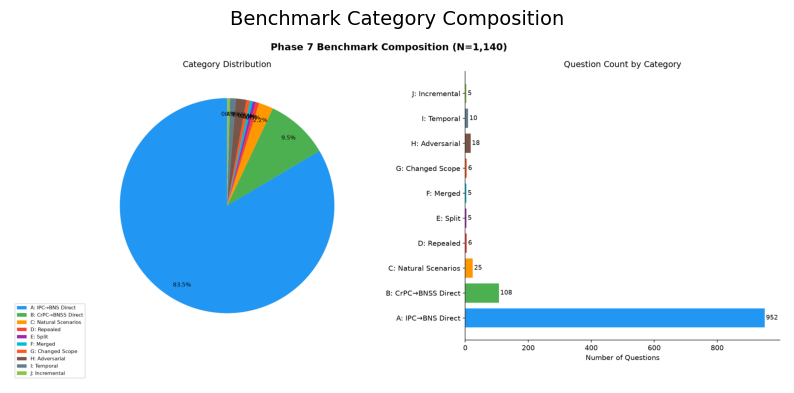

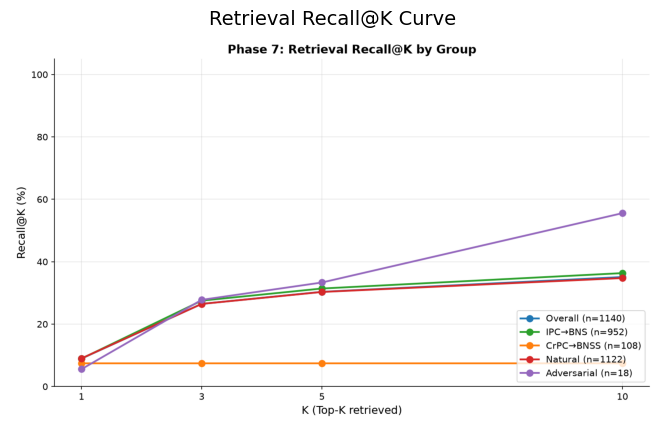

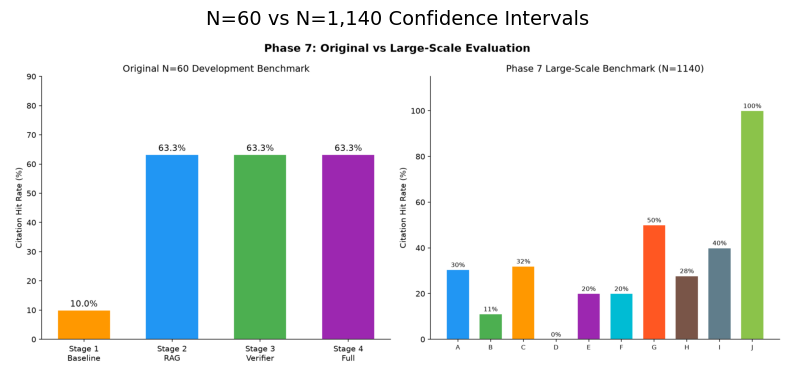

In [7]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

figures = [
    ('fig1_benchmark_composition.png', 'Benchmark Category Composition'),
    ('fig2_retrieval_recall_at_k.png', 'Retrieval Recall@K Curve'),
    ('fig5_original_vs_largescale.png', 'N=60 vs N=1,140 Confidence Intervals'),
]

fig_dir = os.path.join(PROJECT_ROOT, 'phase7', 'results', 'figures')
for f_name, f_title in figures:
    f_path = os.path.join(fig_dir, f_name)
    if os.path.exists(f_path):
        img = mpimg.imread(f_path)
        plt.figure(figsize=(10, 5))
        plt.imshow(img)
        plt.axis('off')
        plt.title(f_title, fontsize=14, pad=10)
        plt.show()


---
## 8. Synchronize Results Back to Google Drive
Persists newly generated tables and reports to `/content/drive/MyDrive/NLP_rspaper`.

In [8]:
if 'LOCAL_ROOT' in locals() and PROJECT_ROOT == LOCAL_ROOT:
    dest_phase7 = os.path.join(DRIVE_ROOT, 'phase7')
    if os.path.exists(dest_phase7):
        shutil.rmtree(dest_phase7)
    shutil.copytree(os.path.join(PROJECT_ROOT, 'phase7'), dest_phase7)

    dest_report = os.path.join(DRIVE_ROOT, 'report')
    if os.path.exists(dest_report):
        for item in os.listdir(os.path.join(PROJECT_ROOT, 'report')):
            s = os.path.join(PROJECT_ROOT, 'report', item)
            d = os.path.join(dest_report, item)
            if os.path.isfile(s):
                shutil.copy2(s, d)
    print('✅ Successfully synced all Phase 7 artifacts back to Google Drive.')
else:
    print('Local run complete. No Drive sync required.')


✅ Successfully synced all Phase 7 artifacts back to Google Drive.
